# 2D spectrum

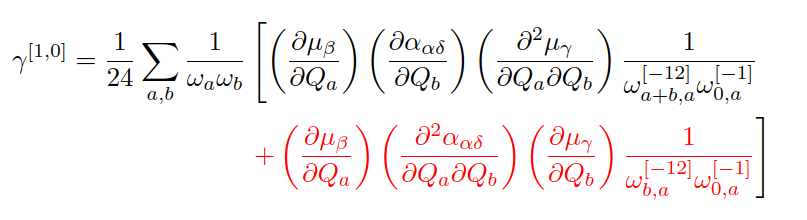

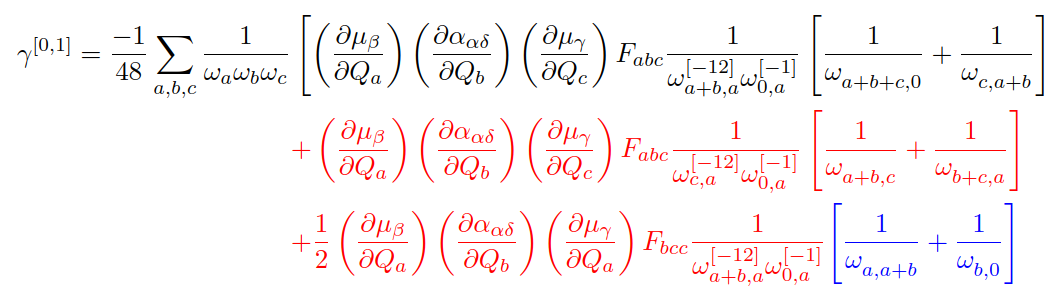

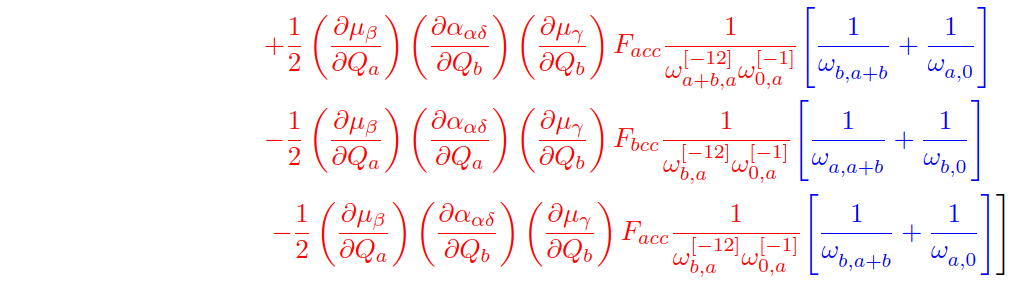

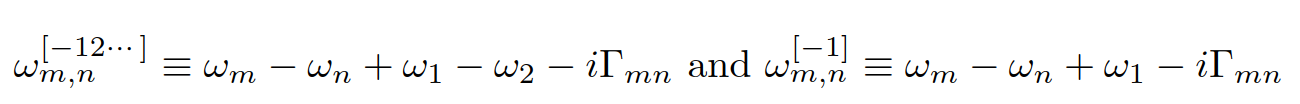

## 1. Orientational averaging (over $\alpha, \beta, \gamma, \delta$)

In [3]:
import numpy as np
np.set_printoptions(linewidth=100000)

# one term function with given pattern of derivatives
def avrgterm(todo, alpha, beta, gamma, delta, dmu, dalpha):
    f = dmu[len(todo[0])-1][(beta,) + todo[0]]
    s = dalpha[len(todo[1])-1][(alpha, delta,) + todo[1]]
    t = dmu[len(todo[2])-1][(gamma,) + todo[2]]

    return f * s * t

# average over given suscept_tensor_comp
def orientavr_total(suscept_tensor_comp, todo, dmu, dalpha):
    ders_avrg = []
    
    for alpha in suscept_tensor_comp[0]:
        for beta in suscept_tensor_comp[1]:
            for gamma in suscept_tensor_comp[2]:
                for delta in suscept_tensor_comp[3]:
                    
                    ders_avrg.append(avrgterm(todo, alpha, beta, gamma, delta, dmu, dalpha))
                    
    avrgders = sum(ders_avrg) / len(ders_avrg)
    return avrgders

## 2. Plotting function

In [96]:
%matplotlib widget
from ipywidgets import *
import matplotlib.pyplot as plt
from matplotlib import cm, ticker, colors

import numpy as np
np.set_printoptions(linewidth=100000)


def rendering2D(X, Y, Z, w1mw2=True):
    # plt.clf()

    # PLOTTING
    fig, ax = plt.subplots()
    fig.set_size_inches(11, 9)

    # print(X)
    # print(Z)

    ax.set_xlabel('w1', fontsize=18)
    
    
    if w1mw2:
        y = (X-Y) 
        ax.set_ylabel('-(w1-w2)', fontsize=18)

    else: 
        y = Y
        ax.set_ylabel('w2', fontsize=18)
    
    cp = ax.contourf(X, y, Z, 8)
    # cp = ax.contourf(X, Y, Z, locator=ticker.LogLocator()) #, cmap=cm.PuBu_r)

    # lev_exp = np.arange(np.floor(np.log10(Z.min())-1),
    #                    np.ceil(np.log10(Z.max())+1))
    # levs = np.array([10**(np.floor(np.log10(Z.min())-1)), 10**(38), 10**(np.ceil(np.log10(Z.max())+1))]) #4 #np.power(10, lev_exp)
    # cp = ax.contour(X, Y, Z, levs, norm=colors.LogNorm())
    
    cb = fig.colorbar(cp)

    # plt.xticks(np.linspace(0, 120, 10))
    ax.set_xticks(np.linspace(min(X.flatten()), max(X.flatten()), 10))
    ax.set_yticks(np.linspace(min(y.flatten()), max(y.flatten()), 10))
    
    # if w1mw2:
        # ax.set_ylim(0, np.max(y))
#     plt.axvline(x=4176.50, color='k', linewidth=0.5)
#     plt.axvline(x=4267.12, color='k', linewidth=0.5)
    
#     plt.axhline(y=4176.50, color='k', linewidth=0.5)
#     plt.axhline(y=4267.12, color='k', linewidth=0.5)
    
    plt.show()

## 3. $\gamma^{[0, 1]}$ - electical anharmonicity, $\gamma^{[0, 1]}$ - mechanical anharmonicity

In [97]:
import copy

t1el = lambda w, w1, w2, Gamma, a, b: \
        1 / (w[''.join(sorted(str(a)+str(b)))] - w[str(a)] + w1 - w2 - 1j*Gamma) / (0. - w[str(a)] + w1 - 1j*Gamma)

t2el = lambda w, w1, w2, Gamma, a, b: \
        1 / (w[str(b)] - w[str(a)] + w1 - w2 - 1j*Gamma) / (0. - w[str(a)] + w1 - 1j*Gamma)

t1mech = lambda w, w1, w2, Gamma, a, b, c: \
        1 / (w[''.join(sorted(str(a)+str(b)))] - w[str(a)] + w1 - w2 - 1j*Gamma) / (0. - w[str(a)] + w1 - 1j*Gamma) * \
       (1 / (w[''.join(sorted(str(a)+str(b)+str(c)))] - 0. +0.0001) \
      + 1 / ( w[str(c)] - w[''.join(sorted(str(a)+str(b)))] +0.0001))

def gamma_mn(Nfund, w1, w2, states, F, Delta):
    w1w1, w2w2 = np.meshgrid(w1, w2)
    total_sum_el = np.zeros(w1w1.shape, dtype=('complex128'))
    total_sum_mech = np.zeros(w1w1.shape, dtype=('complex128'))
    
    new_states = copy.deepcopy(states)
    new_states.update(Delta)
    Gamma = 10**(-6)
    
    for a in range(Nfund):
        for b in range(Nfund):
            # print(a,b, states[str(a)], states[str(a)]+states[str(b)])
            
            prefac_el = 1 #/new_states[str(a)]/new_states[str(b)]
            
            averg_el = 1
            
            # electrical
            total_sum_el += prefac_el * averg_el * t1el(new_states, w1w1, w2w2, Gamma, a, b)
            total_sum_el += prefac_el * averg_el * t2el(new_states, w1w1, w2w2, Gamma, a, b)
            
            for c in range(Nfund):
                # print(Nfund)
                # print('here', a, b, c)
                averg_mech = 1
                prefac_mech = 1 #/new_states[str(a)]/new_states[str(b)]/new_states[str(c)]
                
                # mechanical
                # total_sum_mech += prefac_mech * averg_mech * t1mech(new_states, w1w1, w2w2, Gamma, a, b, c)
                pass
    
    return w1w1, w2w2, (total_sum_el/24.-total_sum_mech/48.)

### Test 1

In [98]:
F = np.zeros((2, 2, 2))
for i in F:
    for j in i: 
        j = 1.
        
Delta = {'00': 40, '11': 60, '22':100, '01': 50, '12': 80, '02': 70, 
         '000':60, '001':70, '011':80, '111':90, '002':90, '022':120, '012':100, '112':110, '122':120, '222':150}
# for i in Delta: Delta[i]=0.

# states = {'0':20, '1':30
#           # , '2':50
#          }
states = {'0': 1775.32, '1': 4176.50, '2': 4267.12}
Delta = {'00': 2*states['0'], '11': 2*states['1'], '22': 2*states['2'], '01': states['0']+states['1'], '12': states['1']+states['2'], 
         '02': states['0']+states['2'], 
         #'000': 3*states['0'], '001': states['0']+states['0']+states['1'], 
         # '011': states['0']+states['1']+states['1'], '111': 3*states['1'], 
         # '002': states['0']+states['0']+states['2'], '022': states['0']+states['2']+states['2'], 
         # '012': states['0']+states['1']+states['2'], '112': states['1']+states['1']+states['2'], 
         # '122': states['1']+states['2']+states['2'], '222': states['2']+states['2']+states['2']
        }
Delta

{'00': 3550.64,
 '11': 8353.0,
 '22': 8534.24,
 '01': 5951.82,
 '12': 8443.619999999999,
 '02': 6042.44}

In [138]:
np.append(np.append(np.arange(0, 40, 5), 42.2), np.arange(43, 49, 5))

array([ 0. ,  5. , 10. , 15. , 20. , 25. , 30. , 35. , 42.2, 43. , 48. ])

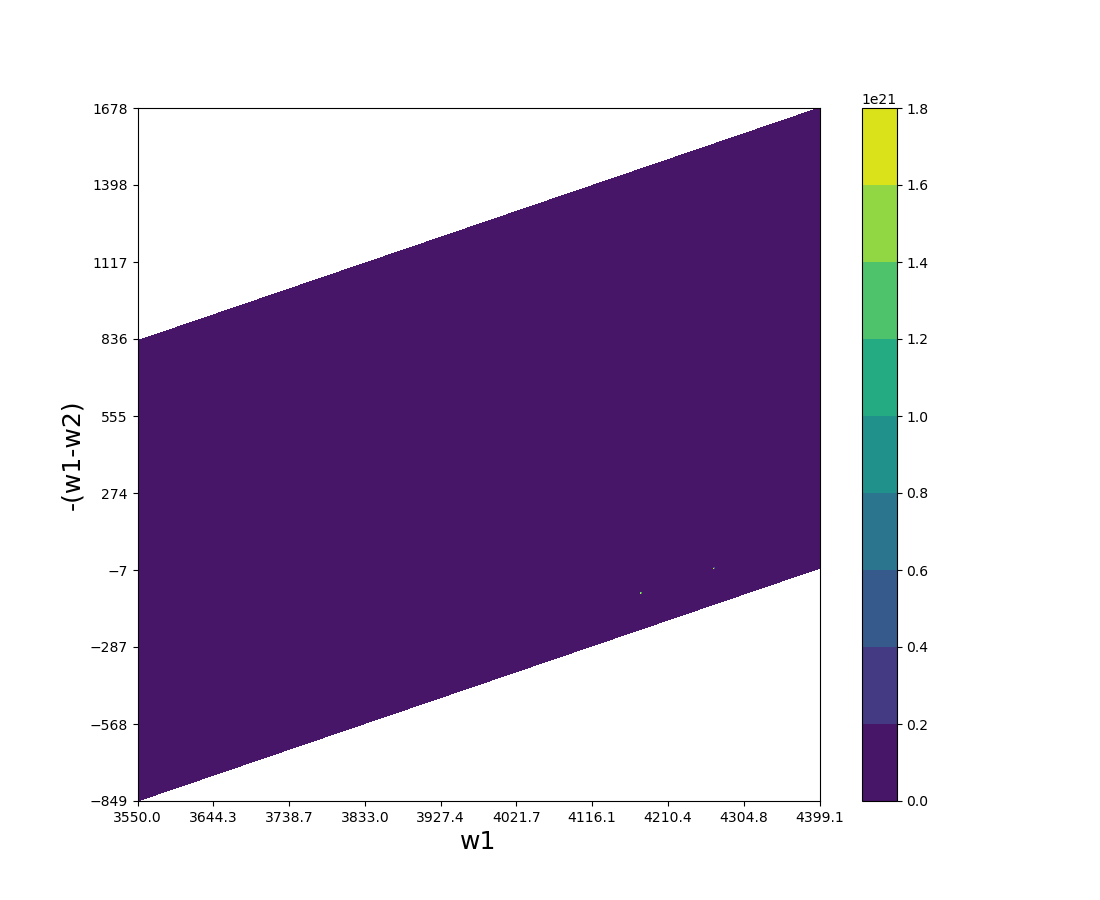

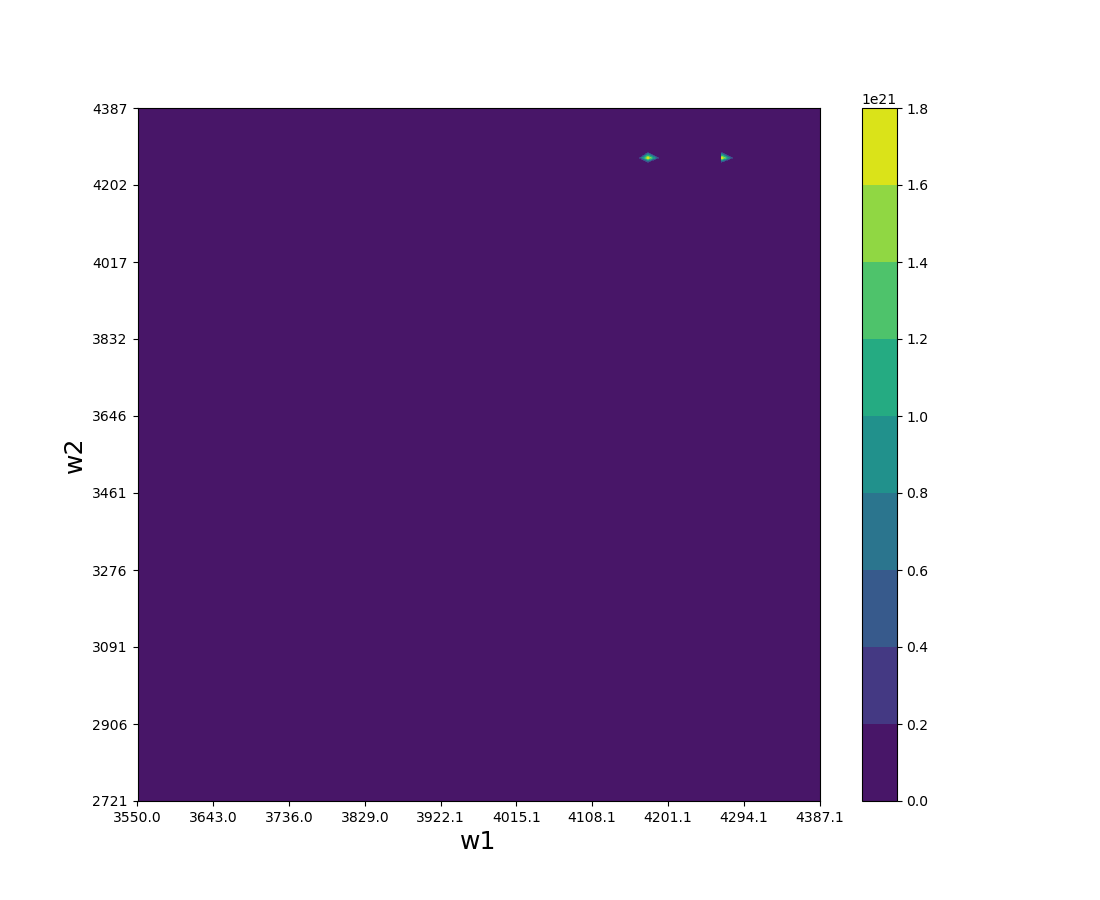

In [99]:
# states = {'':0., '0':30, '1':40, '00':60, '11': 80, '01':70}
Nfund = len(states)
# aa, bb, cc, dd = 0, 71, 15, 110
w2 = np.arange(1775.32*2-30., 4500, 1.01)
# w1 = np.arange(4000, 9300, 1.01)
dd = 1
w1 = np.append(np.append(np.append(np.arange(3550, 4176.50, dd), 4176.50), np.append(np.arange(4176.50, 4267.12, dd), 4267.12)), np.arange(4267.12, 4400, dd))
w2 = np.append(np.append(np.append(np.arange(1375.32*2-30., 1775.32*2, dd), 1775.32*2), np.append(np.arange(1775.32*2, 4267.12, dd), 4267.12)), np.arange(4267.12, 4400, dd))


X, Y, zz = gamma_mn(Nfund, w1, w2, states, F, Delta)
Z = abs(zz)**2
# Z = zz.real
# Z = zz.imag

rendering2D(X, Y, Z, w1mw2=True)

w1 = np.append(np.append(np.append(np.arange(3550, 4176.50, 15), 4176.50), np.append(np.arange(4176.50, 4267.12, 15), 4267.12)), np.arange(4267.12, 4400, 15))
w2 = np.append(np.append(np.append(np.arange(1375.32*2-30., 1775.32*2, 15), 1775.32*2), np.append(np.arange(1775.32*2, 4267.12, 15), 4267.12)), np.arange(4267.12, 4400, 15))


X, Y, zz = gamma_mn(Nfund, w1, w2, states, F, Delta)
Z = abs(zz)**2

rendering2D(X, Y, Z, w1mw2=False)

## Resonance Term class

In [126]:
import copy
import numpy as np
np.set_printoptions(linewidth=100000)

class Omega_resonance:
    
    def __init__(self, m, n, superscript):
        '''
        m, n: str, str
        
        '''
        self.m = m
        self.n = n
        self.superscript = superscript
        # self.Nmodes_interm = Nmodes_interm
        
        self.dictsMN = []
        
        one = {} if '0' in self.m else {i: 1 for i in self.m.split("+")}
        if '+' in self.m: one[''.join(one.keys())] = 1
        self.dictsMN.append(one)
        
        two = {} if '0' in self.n else {i: 1 for i in self.n.split("+")}
        if '+' in self.n: two.update({''.join(two.keys()): 1})
        self.dictsMN.append(two)
        
        self.final = copy.deepcopy(one)
        for km, vm in one.items():
            if km in two: 
                self.final[km] = one[km]-two[km]
                if self.final[km]==0: del self.final[km]
        for kn, vn in two.items():
            if kn not in one: self.final[kn] = -vn
        
        self.resonance = '+'.join([str(v)[:-1]+'w_'+k for k,v in self.final.items()])
        if "+-" in self.resonance: 
            self.resonance = self.resonance.replace('+-', ' - ')
        self.resonance = self.resonance.replace('+', ' + ')
        
        # if self.superscript == '-1':
        #     print('w1 resonance')
        # elif self.superscript == '-12':
        #     print('w1-w2 resonance')
            
    def compute(self, states, Delta, w1w1, w2w2, a, b, c=None):
                
        Gamma = 0.00001
        ss1 = self.computeR(states, Delta, a, b, c)
        
        if self.superscript == '-1':
            res = 1 / (ss1+w1w1-1j*Gamma)
        elif self.superscript == '-12':
            res = 1 / (ss1+w1w1-w2w2-1j*Gamma)
        elif self.superscript == '':
            res = 1 / (ss1)
        
        return res
    
    def computeR(self, states, Delta, a, b, c=None, w1=None):
        
        mapping = {'a':a, 'b': b, 'c': c, 'ab': str(a)+str(b), 'abc': str(a)+str(b)+str(c)}
        new_states = copy.deepcopy(states)
        new_states.update(Delta)
        
        s1 = [v*new_states[''.join(sorted(str(mapping[k])))] for k, v in self.final.items() if mapping[k] is not None]
        # print(s1)
        ss1 = sum(s1)
        
        return ss1
    
    def get_resonance_freqs(self, states, Delta, Nmodes_interm):
        res_freqs = {'w1': {}, 'w1mw2': {}, 'fermi': {}}
        import itertools

        all_possible_variables = np.arange(len(states))
        
        list_of_vars = [all_possible_variables] * Nmodes_interm
        arbitrary_abc = list(itertools.product(*list_of_vars))
                
        for abc in arbitrary_abc:
            c = abc[2] if len(abc)>2 else None
            curr = self.computeR(states, Delta, a=abc[0], b=abc[1], c=c)
               
            if self.superscript == '-1':
                res_freqs['w1'][abc] = curr

            elif self.superscript == '-12':
                res_freqs['w1mw2'][abc] = curr
                # res_freqs['w2'][abc] = curr

            elif self.superscript == '':
                res_freqs['fermi'][abc] = curr
        
        return res_freqs

In [127]:
#--------------------------------------------
w1 = np.arange(0., 82, 1)
w2 = np.arange(0, 82, 1)
X, Y = np.meshgrid(w1, w2)

states = {'0':20, '1':30
          # , '2':50
         }
states = {'0': 1775.32, '1': 4176.50, '2': 4267.12}

Delta = {'00': 40, '11': 60, '22':100, '01': 50, '12': 80, '02': 70, 
         '000':60, '001':70, '011':80, '111':90, '002':90, '022':120, '012':100, '112':110, '122':120, '222':150}


for i in Delta: Delta[i]=0.
#--------------------------------------------

# a, b = Omega_resonance('a+b+c', '0', '-1').dictsMN
# a, b = Omega_resonance('0', 'a', '-1').dictsMN
# a, b = Omega_resonance('a+b', 'a', '-1').dictsMN

tt1 = Omega_resonance('a+b', 'a', '-12')
tt2 = Omega_resonance('0', 'a', '-1')
# tt2 = Omega_resonance('c', 'a', '-1')
# tt2 = Omega_resonance('c', 'a+b', '')


# tt2.final
# print(X.shape)
# print(tt2.compute(states, Delta, X, Y, 0, 0, 0))
print(tt2.resonance)
print(states)
c = tt1.get_resonance_freqs(states, Delta, Nmodes_interm=2)
d = tt2.get_resonance_freqs(states, Delta, Nmodes_interm=2)

print('w1   ', d['w1'])
print('w1mw2', c['w1mw2'])

-w_a
{'0': 1775.32, '1': 4176.5, '2': 4267.12}
w1    {(0, 0): -1775.32, (0, 1): -1775.32, (0, 2): -1775.32, (1, 0): -4176.5, (1, 1): -4176.5, (1, 2): -4176.5, (2, 0): -4267.12, (2, 1): -4267.12, (2, 2): -4267.12}
w1mw2 {(0, 0): 1775.32, (0, 1): 4176.5, (0, 2): 4267.12, (1, 0): 1775.32, (1, 1): 4176.5, (1, 2): 4267.12, (2, 0): 1775.32, (2, 1): 4176.5, (2, 2): 4267.12}


## Lorentzian lineshape

In [ ]:
x = 
y = 1/(x-2-0.0001)/(x-0.0001)

plt.plot()

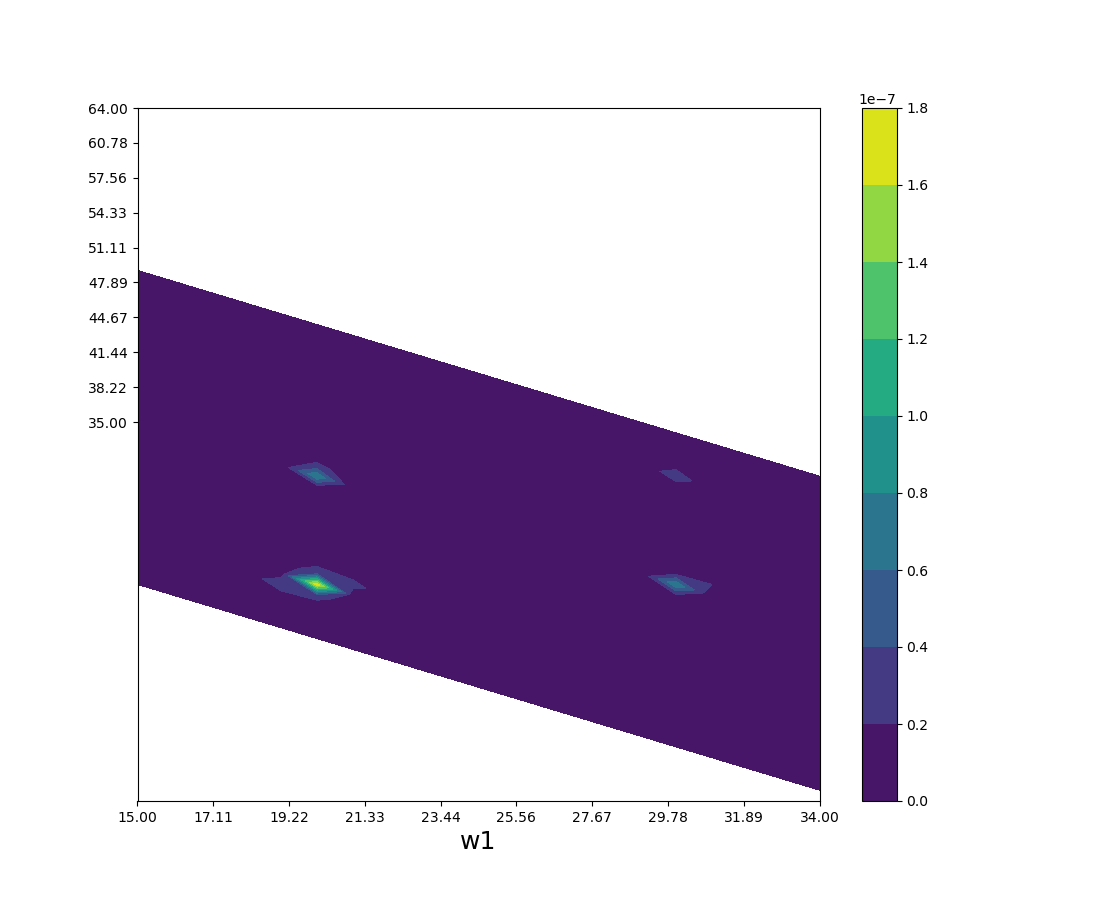

In [32]:
# states = {'':0., '0':30, '1':40, '00':60, '11': 80, '01':70}
Nfund = len(states)
# aa, bb, cc, dd = 0, 71, 15, 110
w1 = np.arange(15., 35, 1.)
w2 = np.arange(35, 65, 1.)

X, Y, zz = gamma_mn(Nfund, w1, w2, states, F, Delta)
Z = abs(zz)**2
# Z = zz.real
# Z = zz.imag

rendering2D(X, Y, Z, w1mw2=True)

## Quantum states

In [ ]:
class Qstate():
    
    def __init__(self, freqs, Deltas):
        self.freqs = freqs
        self.Deltas = Deltas
    
    # from |n, k> get w_s
    def get_state(wf_state, Nstates):
        final = 0
        
        for i in wf_state:
            
        

In [ ]:
def gamma_el_ab():
    pass

def gamma_mech_ab():
    pass



## New class

In [47]:
import copy
import numpy as np
np.set_printoptions(linewidth=100000)

%matplotlib widget
from ipywidgets import *


class spectrumEVV:
    
    def __init__(self, w1, w2, fundamentals, Gamma):
        
        self.w1, self.w2 = np.meshgrid(w1, w2)
        self.shape2d = self.w1.shape
        self.fundamentals = fundamentals
        
        self.fermirm = 0.0001
        
        self.t1el = lambda w, w1, w2, Gamma, a, b: \
            1 / (w[''.join(sorted(str(a)+str(b)))] - w[str(a)] + w1 - w2 - 1j*Gamma) / (0. - w[str(a)] + w1 - 1j*Gamma)

        self.t2el = lambda w, w1, w2, Gamma, a, b: \
            1 / (w[str(b)] - w[str(a)] + w1 - w2 - 1j*Gamma) / (0. - w[str(a)] + w1 - 1j*Gamma)

        self.t1mech = lambda w, w1, w2, Gamma, a, b, c: \
            1 / (w[''.join(sorted(str(a)+str(b)))] - w[str(a)] + w1 - w2 - 1j*Gamma) / (0. - w[str(a)] + w1 - 1j*Gamma) * \
           (1 / (w[''.join(sorted(str(a)+str(b)+str(c)))] - 0. + self.fermirm) \
          + 1 / ( w[str(c)] - w[''.join(sorted(str(a)+str(b)))] + self.fermirm))
        
        elements = list(self.fundamentals.keys())
        pairs = [a + b for i, a in enumerate(elements) for b in elements[i:]]
        triples = [a + b + c for i, a in enumerate(elements) for j, b in enumerate(elements[i:]) for c in elements[j:]]

        self.Delta = {k:sum([self.fundamentals[i] for i in k]) for k in [*pairs, *triples]}
        
        self.Gamma = Gamma
    
    def gamma_mn(self, a, b, c=False):
        # if type(c)==bool:
        #     a, b = np.meshgrid(a, b)
        # else:
        #     a, b, c = np.meshgrid(a, b, c)
        
        if type(c)==bool:
            
            total_sum_el = np.zeros(self.shape2d, dtype=('complex128'))

            new_states = copy.deepcopy(self.fundamentals)
            new_states.update(self.Delta)
            

            # for a in range(len(self.fundamentals)):
            #     for b in range(len(self.fundamentals)):

            averg_el = 1
            prefac_el = 1 / self.fundamentals[str(a)] / self.fundamentals[str(b)]

            # electrical
            total_sum_el += prefac_el * averg_el * self.t1el(new_states, self.w1, self.w2, self.Gamma, a, b)
            # total_sum_el += prefac_el * averg_el * self.t2el(new_states, self.w1, self.w2, self.Gamma, a, b)
            
            return total_sum_el/24
            
        else:
            
            total_sum_mech = np.zeros(self.shape2d, dtype=('complex128'))
            
            # mechanical
            averg_mech = 1
            prefac_mech = 1 / self.fundamentals[str(a)] / self.fundamentals[str(b)] / self.fundamentals[str(c)]

            total_sum_mech += prefac_mech * averg_mech * t1mech(new_states, w1w1, w2w2, self.Gamma, a, b, c)

            return -total_sum_mech/48.
    
    
    def plot2D(self, w1mw2=False):
        import matplotlib.pyplot as plt
        from matplotlib import cm, ticker, colors
    
    # def rendering2D(X, Y, Z, w1mw2=True):
        # plt.clf()
        X, Y = self.w1, self.w2
        a, b, c = np.arange(len(self.fundamentals)), np.arange(len(self.fundamentals)), np.arange(len(self.fundamentals))
        
        coords_ab = get_abc(2, len(self.fundamentals))
        coords_ab = [[0, 0], [0, 1]]
        Z = np.zeros(self.shape2d, dtype=('complex128'))
        
        for i in coords_ab:
            print(i)
            added = self.gamma_mn(i[0], i[1])
            # for k in self.fundamentals:
            x_index = np.where(self.w1 == self.fundamentals[str(i[0])])[0][0]
            y_index = np.where(self.w2 == self.fundamentals[str(i[1])])[0][0]
            print(added[y_index, x_index])
            
            Z += self.gamma_mn(i[0], i[1])
        
        # print(Z)
        
        # PLOTTING
        fig, ax = plt.subplots()
        fig.set_size_inches(11, 9)

        ax.set_xlabel('w1', fontsize=18)

        if w1mw2:
            y = (X-Y) 
            ax.set_ylabel('-(w1-w2)', fontsize=18)

        else: 
            y = Y
            ax.set_ylabel('w2', fontsize=18)

        cp = ax.contourf(X, y, abs(Z)**2, 8)
        # cp = ax.contourf(X, Y, Z, locator=ticker.LogLocator()) #, cmap=cm.PuBu_r)

        # lev_exp = np.arange(np.floor(np.log10(Z.min())-1),
        #                    np.ceil(np.log10(Z.max())+1))
        # levs = np.array([10**(np.floor(np.log10(Z.min())-1)), 10**(38), 10**(np.ceil(np.log10(Z.max())+1))]) #4 #np.power(10, lev_exp)
        # cp = ax.contour(X, Y, Z, levs, norm=colors.LogNorm())

        cb = fig.colorbar(cp)

        # plt.xticks(np.linspace(0, 120, 10))
        ax.set_xticks(np.linspace(min(X.flatten()), max(X.flatten()), 10))
        ax.set_yticks(np.linspace(min(y.flatten()), max(y.flatten()), 10))

        # if w1mw2:
            # ax.set_ylim(0, np.max(y))
        # for f in  self.fundamentals:
        #     plt.axvline(x=f, color='k', linewidth=0.5)
        #     plt.axhline(y=f, color='k', linewidth=0.5)
            
        plt.show()


def get_abc(nloops, abcrange):
    stacklist = []
    for i in range(nloops):
        stacklist.append(np.arange(abcrange))
    
    return np.stack(np.meshgrid(*stacklist), axis=-1).reshape(-1, nloops)

[0, 0]
(-2.6025323502421323e-07-1.038546944385103e-05j)
[0, 1]
(-1.7350215668280882e-07-6.923646295900687e-06j)


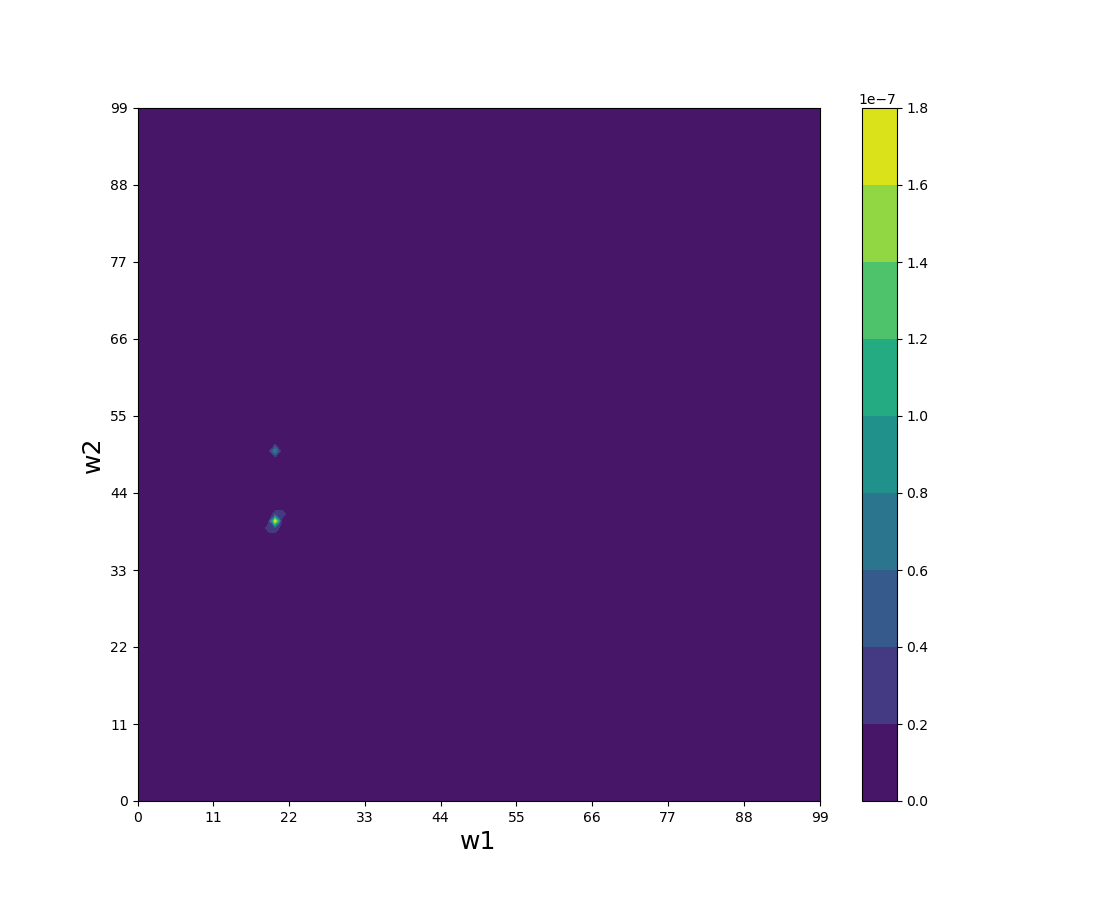

In [48]:
w1 = np.arange(0., 100, 1.)
w2 = np.arange(0, 100, 1.)
X, Y = np.meshgrid(w1, w2)

fundamentals = {'0':20, '1':30
           , '2':50
         }

h = spectrumEVV(w1, w2, fundamentals, Gamma=10**(-0.3))
h.Delta
h.plot2D()

In [75]:
def notry(a, b, c=0):
    if c==0:
        return a+b
    else:
        return a+b+c

a, b, c = np.array([0, 1, 10]), np.array([1, 10, 100]), np.array([10, 100, 1000])
aaa, bbb, ccc = np.meshgrid(a, b, c)
aa, bb = np.meshgrid(a, b)

# aaa[0]==aa
print(aa)
print('-----------')
print(bb)
print('-----------')
# print(ccc)
# print(aaa[0])
# notry(aa, bb)
print('-----------')
# notry(aaa, bbb, ccc)
notry(aa, bb)

[[ 0  1 10]
 [ 0  1 10]
 [ 0  1 10]]
-----------
[[  1   1   1]
 [ 10  10  10]
 [100 100 100]]
-----------
-----------


array([[  1,   2,  11],
       [ 10,  11,  20],
       [100, 101, 110]])

In [85]:
def notry(a, b, c=False):
    if type(c)==bool:
        return a+b
    else:
        return a+b+c

a, b, c = np.array([0, 1, 10]), np.array([1, 10, 100]), np.array([10, 100, 1000])
a, b, c = np.array([0, 1, 10]), np.array([0, 1, 10]), np.array([0, 1, 10])
aaa, bbb, ccc = np.meshgrid(a, b, c)
aa, bb = np.meshgrid(a, b)

# aaa[0]==aa
print(aaa)
print('-----------')
print(bbb)
print('-----------')
# print(ccc)
# print(aaa[0])
# notry(aa, bb)
print('-----------')
notry(aaa, bbb.T)
# notry(aa, bb)

[[[ 0  0  0]
  [ 1  1  1]
  [10 10 10]]

 [[ 0  0  0]
  [ 1  1  1]
  [10 10 10]]

 [[ 0  0  0]
  [ 1  1  1]
  [10 10 10]]]
-----------
[[[ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]]

 [[ 1  1  1]
  [ 1  1  1]
  [ 1  1  1]]

 [[10 10 10]
  [10 10 10]
  [10 10 10]]]
-----------
-----------


array([[[ 0,  1, 10],
        [ 1,  2, 11],
        [10, 11, 20]],

       [[ 0,  1, 10],
        [ 1,  2, 11],
        [10, 11, 20]],

       [[ 0,  1, 10],
        [ 1,  2, 11],
        [10, 11, 20]]])

In [91]:
import numpy as np
a = np.arange(3)
b = np.arange(3)
c = np.arange(3)

aa, bb, cc = np.meshgrid(a, b, c)
aa
# # Reshape coordinates
coordinates = np.stack([aa, bb, cc], axis=-1).reshape(-1, 3)
# coordinates

def get_abc(nloops, abcrange):
    stacklist = []
    for i in range(nloops):
        stacklist.append(np.arange(abcrange))
    
    return np.stack(np.meshgrid(*stacklist), axis=-1).reshape(-1, nloops)

get_abc(2, 3)

array([[0, 0],
       [1, 0],
       [2, 0],
       [0, 1],
       [1, 1],
       [2, 1],
       [0, 2],
       [1, 2],
       [2, 2]])

In [38]:
elements = ['0', '1', '2']

# Generate pairs
pairs = [a + b for i, a in enumerate(elements) for b in elements[i:]]
print("Pairs:")
print(pairs)

# Generate triples
triples = [a + b + c for i, a in enumerate(elements) for j, b in enumerate(elements[i:]) for c in elements[j:]]
print("Triples:")
print(triples)


Pairs:
['00', '01', '02', '11', '12', '22']
Triples:
['000', '001', '002', '011', '012', '022', '110', '111', '112', '121', '122', '220', '221', '222']
